# Hist movements + FX (USD/ILS) + market history

Standalone exploration: `trade_portfolio_position` in `data/ledger.sqlite`, bank exports under `hist-data/*.xls`, **TASE/Maya** via `pymaya`, and Yahoo/OpenFIGI for global prices.

**Setup** (from repo root):

```bash
pip install -r notebooks/requirements-notebooks.txt
```

Then open this notebook and run all cells. Paths default to `FinCompiler` repo layout.

In [52]:
from __future__ import annotations

import json
import re
import sqlite3
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

import pandas as pd
import requests

# Repo root = parent of notebooks/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

LEDGER_DB = REPO_ROOT / "data" / "ledger.sqlite"
HIST_GLOB = REPO_ROOT / "hist-data" / "*.xls"
ENRICHED_DIR = REPO_ROOT / "hist-data" / "enriched"
MANUAL_TICKER_CSV = REPO_ROOT / "notebooks" / "security_yahoo_map.csv"

JOIN_DATE_COL = "pay_date_iso"  # use "exec_date_iso" if you prefer economic date from execution

print("REPO_ROOT", REPO_ROOT)
print("LEDGER_DB exists", LEDGER_DB.is_file())

REPO_ROOT c:\DEV\FinCompiler
LEDGER_DB exists True


In [53]:
# --- SpreadsheetML: standalone parse for "תנועות היסטוריות" exports ---

_SS_NS = "urn:schemas-microsoft-com:office:spreadsheet"


def _tag(local: str) -> str:
    return f"{{{_SS_NS}}}{local}"


def _norm_header(s: object) -> str:
    if s is None:
        return ""
    return re.sub(r"\s+", " ", str(s).strip())


_AMP_NOT_ENTITY = re.compile(r"&(?!([a-zA-Z][a-zA-Z0-9.:-]{0,63}|#[0-9]+|#x[0-9a-fA-F]+);)")


def _escape_bare_ampersands_xml(text: str) -> str:
    return _AMP_NOT_ENTITY.sub("&amp;", text)


def _load_spreadsheetml_element_tree(path: Path) -> ET.ElementTree:
    raw = path.read_bytes()
    text = raw.decode("utf-8-sig", errors="replace").lstrip()
    if not text.startswith("<?xml") and not text.startswith("<Workbook"):
        i_xml = text.find("<?xml")
        i_wb = text.find("<Workbook")
        candidates = [i for i in (i_xml, i_wb) if i >= 0]
        if not candidates:
            raise ValueError(f"no <?xml or <Workbook in {path!r}")
        text = text[min(candidates) :]
    text = _escape_bare_ampersands_xml(text)
    root = ET.fromstring(text)
    return ET.ElementTree(root)


def _cell_value(cell: ET.Element):
    data = cell.find(_tag("Data"))
    if data is None:
        return None
    raw = (data.text or "").strip()
    typ = data.get(f"{{{_SS_NS}}}Type") or "String"
    if typ == "Number":
        if raw == "":
            return None
        try:
            return float(raw)
        except ValueError:
            return None
    return raw if raw else None


def _row_cell_values(row_el: ET.Element) -> list:
    col_idx = 0
    out: list = []
    for cell in row_el.findall(_tag("Cell")):
        idx_attr = cell.get(f"{{{_SS_NS}}}Index")
        if idx_attr is not None:
            col_idx = int(idx_attr) - 1
        while len(out) <= col_idx:
            out.append(None)
        out[col_idx] = _cell_value(cell)
        col_idx += 1
    return out


def _pair_after_label(flat: list, label: str) -> str | None:
    for i, c in enumerate(flat):
        if c is None:
            continue
        if str(c).strip() == label and i + 1 < len(flat):
            nxt = flat[i + 1]
            if nxt is None:
                return None
            return str(nxt).strip()
    return None


HIST_HEADER_ALIASES: dict[str, str] = {
    "מספר נייר": "security_number",
    "שם": "name",
    "פעולה": "action",
    "תאריך ביצוע": "exec_date_raw",
    "תאריך תשלום": "pay_date_raw",
    "כמות": "quantity",
    "שער": "unit_price",
    "תמורה": "consideration",
    "עמלה": "commission",
    "מס": "tax",
    "מטבע": "currency",
}


def parse_hist_date(val) -> str | None:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return None
    if isinstance(val, (int, float)) and not isinstance(val, bool):
        return None
    s = str(val).strip()
    if not s:
        return None
    for fmt in ("%d/%m/%Y", "%d.%m.%y", "%d.%m.%Y", "%Y-%m-%d"):
        try:
            return datetime.strptime(s[:10] if len(s) > 10 else s, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    # export-style datetime e.g. 12.05.26 15:24
    m = re.match(r"(\d{1,2})\.(\d{1,2})\.(\d{2,4})", s)
    if m:
        d, mo, y = m.groups()
        yi = int(y)
        if yi < 100:
            yi += 2000
        try:
            return datetime(int(yi), int(mo), int(d)).strftime("%Y-%m-%d")
        except ValueError:
            return None
    return None


def parse_hist_workbook(path: Path) -> tuple[str | None, str | None, list[dict]]:
    """Returns (export_meta_raw, portfolio_account, rows)."""
    tree = _load_spreadsheetml_element_tree(path)
    root = tree.getroot()
    table = root.find(f".//{_tag('Table')}")
    if table is None:
        raise ValueError(f"no Table in {path}")

    export_raw: str | None = None
    portfolio_meta: str | None = None
    header_fields: list[str | None] | None = None
    data_rows: list[dict] = []

    for row_el in table.findall(_tag("Row")):
        flat = _row_cell_values(row_el)
        if not any(v is not None and str(v).strip() != "" for v in flat):
            continue

        if export_raw is None:
            sd = _pair_after_label(flat, "תאריך:")
            if sd:
                export_raw = sd
        if portfolio_meta is None:
            pa = _pair_after_label(flat, "תיק:")
            if pa:
                portfolio_meta = pa

        if header_fields is None:
            h0 = flat[0] if flat else None
            if h0 is not None and str(h0).strip() == "מספר נייר":
                header_fields = []
                for c in flat:
                    nh = _norm_header(c)
                    header_fields.append(HIST_HEADER_ALIASES.get(nh))
                continue

        if header_fields is None:
            continue

        rec: dict = {"source_file": path.name}
        for idx, field in enumerate(header_fields):
            if field is None or idx >= len(flat):
                continue
            rec[field] = flat[idx]

        sec = rec.get("security_number")
        if sec is None or str(sec).strip() == "":
            continue
        rec["security_number"] = str(sec).strip()
        rec["portfolio_account"] = portfolio_meta
        rec["export_reported_at"] = export_raw
        data_rows.append(rec)

    return export_raw, portfolio_meta, data_rows


def load_all_hist_xls(pattern: Path) -> pd.DataFrame:
    paths = sorted(pattern.parent.glob(pattern.name))
    all_rows: list[dict] = []
    for p in paths:
        if not p.is_file():
            continue
        _, _, rows = parse_hist_workbook(p)
        all_rows.extend(rows)
    return pd.DataFrame(all_rows)


ISIN_RE = re.compile(r"^[A-Z]{2}[A-Z0-9]{9}[0-9]$")


def looks_like_isin(security_number: str) -> bool:
    s = security_number.strip().upper()
    return bool(ISIN_RE.match(s))


print("parse_hist_workbook defined")

parse_hist_workbook defined


In [54]:
# --- Load ledger positions + all hist exports ---

def load_portfolio_securities(db_path: Path) -> pd.DataFrame:
    sql = """
    SELECT DISTINCT security_number,
           MAX(security_name) AS security_name,
           MIN(snapshot_date) AS first_snapshot,
           MAX(snapshot_date) AS last_snapshot
    FROM trade_portfolio_position
    GROUP BY security_number
    ORDER BY security_number
    """
    conn = sqlite3.connect(str(db_path))
    try:
        return pd.read_sql_query(sql, conn)
    finally:
        conn.close()


if not LEDGER_DB.is_file():
    raise FileNotFoundError(f"Missing {LEDGER_DB} — adjust LEDGER_DB or run portfolio import first.")

positions_df = load_portfolio_securities(LEDGER_DB)
display(positions_df.head(20))
print("distinct securities", len(positions_df))

hist_df = load_all_hist_xls(HIST_GLOB)
if hist_df.empty:
    raise FileNotFoundError(f"No rows from {HIST_GLOB}")

hist_df["exec_date_iso"] = hist_df["exec_date_raw"].map(parse_hist_date)
hist_df["pay_date_iso"] = hist_df["pay_date_raw"].map(parse_hist_date)
hist_df["is_isin"] = hist_df["security_number"].map(looks_like_isin)

merged_names = hist_df.merge(
    positions_df[["security_number", "security_name"]],
    on="security_number",
    how="left",
    suffixes=("", "_ledger"),
)
hist_df = merged_names
display(hist_df.head(15))
print("hist rows", len(hist_df), "from files", hist_df["source_file"].nunique())

,security_number,security_name,first_snapshot,last_snapshot
0,1146067,קסם DJ US Dividend ETF,2024-08-26,2026-05-12
1,1148162,אי בי אי סל S&P 500,2023-08-15,2026-05-12
2,1194182,"הראל אסטרטגיות מניות חו""ל - קרן גידור בנאמנות",2024-08-30,2024-09-02
3,1194976,הראל אסטרטגיות מניות חול גידור 03/23,2025-01-05,2026-05-12
4,1201508,הראל אלפי בנדק US Equity AI QUANT Strategy - ק...,2024-08-30,2024-09-02
5,1210756,הרל.אסמנח 08/24,2024-09-02,2025-01-05
6,1210764,הרל.seqai 08/24,2024-09-02,2025-05-29
7,5105531,אלטשולר שחם S&P 500,2024-08-22,2025-01-01
8,5105895,אלטשולר שחם - קרן ממונפת,2024-08-22,2025-01-01
9,5110374,הראל מניות דיבידנד,2024-08-26,2025-01-02


distinct securities 20


,source_file,security_number,name,action,exec_date_raw,pay_date_raw,quantity,unit_price,consideration,commission,tax,currency,portfolio_account,export_reported_at,exec_date_iso,pay_date_iso,is_isin,security_name
0,2תנועות היסטוריות.xls,60013157,(ספיידר S&P 500) SPY,דיבידנד,NaN,31/10/2023,0.0,0.00,20.58,0.00,-5.15,"דולר ארה""ב",954-037317/51,12.05.26 15:26,NaN,2023-10-31,False,(ספיידר S&P 500) SPY
1,2תנועות היסטוריות.xls,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,דיבידנד,NaN,27/09/2023,0.0,0.00,0.34,0.00,-0.08,"דולר ארה""ב",954-037317/51,12.05.26 15:26,NaN,2023-09-27,False,(פרו-שיירס אולטרה-פרו S&P 500) UPRO
2,2תנועות היסטוריות.xls,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,דיבידנד,NaN,27/09/2023,0.0,0.00,-0.34,0.00,0.08,"דולר ארה""ב",954-037317/51,12.05.26 15:26,NaN,2023-09-27,False,(פרו-שיירס אולטרה-פרו S&P 500) UPRO
3,2תנועות היסטוריות.xls,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,קניה,05/09/2023,07/09/2023,6.0,48.44,-290.64,26.53,0.00,"דולר ארה""ב",954-037317/51,12.05.26 15:26,2023-09-05,2023-09-07,False,(פרו-שיירס אולטרה-פרו S&P 500) UPRO
4,2תנועות היסטוריות.xls,60013157,(ספיידר S&P 500) SPY,קניה,22/08/2023,24/08/2023,13.0,438.65,-5702.45,24.21,0.00,"דולר ארה""ב",954-037317/51,12.05.26 15:26,2023-08-22,2023-08-24,False,(ספיידר S&P 500) SPY
5,2תנועות היסטוריות.xls,720011,אנלייט אנרגיה,קניה וביטול,NaN,21/08/2023,0.0,0.00,0.00,0.00,0.00,"ש""ח",954-037317/51,12.05.26 15:26,NaN,2023-08-21,False,NaN
6,2תנועות היסטוריות.xls,1148162,אי בי אי סל S&P 500,קניה,16/08/2023,17/08/2023,30.0,16290.00,-4887.00,26.00,0.00,"ש""ח",954-037317/51,12.05.26 15:26,2023-08-16,2023-08-17,False,אי בי אי סל S&P 500
7,2תנועות היסטוריות.xls,1148162,אי בי אי סל S&P 500,קניה,14/08/2023,15/08/2023,73.0,16330.00,-11920.90,47.68,0.00,"ש""ח",954-037317/51,12.05.26 15:26,2023-08-14,2023-08-15,False,אי בי אי סל S&P 500
8,3תנועות היסטוריות.xls,60013157,(ספיידר S&P 500) SPY,דיבידנד,NaN,30/04/2024,0.0,0.00,20.73,0.00,-5.18,"דולר ארה""ב",954-037317/51,12.05.26 15:27,NaN,2024-04-30,False,(ספיידר S&P 500) SPY
9,3תנועות היסטוריות.xls,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,דיבידנד,NaN,27/03/2024,0.0,0.00,0.74,0.00,-0.18,"דולר ארה""ב",954-037317/51,12.05.26 15:27,NaN,2024-03-27,False,(פרו-שיירס אולטרה-פרו S&P 500) UPRO


hist rows 115 from files 8


## Holding windows and bank line renames

**`event_date`** matches downstream joins: primary column is `JOIN_DATE_COL` (usually `pay_date_iso`), then `exec_date_iso` when pay is missing — **settlement-oriented**.

**Lots** are inferred from **signed `quantity`**: buys (`קניה`) are positive, sells (`מכירה`) negative in your exports. Rows with **zero quantity** (e.g. `דיבידנד`, `קניה וביטול`) do not move position. **Multiple segments** = round-trips (buy → flat → buy again).

**Renames** = more than one distinct bank `name` string for the same `security_number` over time (same id only; spin-offs / new ids are out of scope).

Outputs: in-memory `hist_holding_segments`, `hist_holding_security_rollup`, `hist_security_name_timeline`; CSVs under `hist-data/enriched/` when the code cell runs.

In [55]:
# --- Holding windows + name timeline (no API calls; uses hist_df after ISO + ledger merge) ---

DEDUPE_HIST_MOVEMENTS = False

_hw = hist_df.copy()
_hw["event_date"] = pd.to_datetime(
    _hw[JOIN_DATE_COL].fillna(_hw["exec_date_iso"]),
    errors="coerce",
)
_hw["quantity"] = pd.to_numeric(_hw["quantity"], errors="coerce")
_hw["action"] = _hw["action"].fillna("").astype(str).str.strip()
_hw["action"] = _hw["action"].replace({"nan": ""})

print("action value_counts (all hist rows):")
print(_hw["action"].value_counts(dropna=False).to_string())
print()

_KNOWN_ACTIONS = frozenset({"קניה", "מכירה", "דיבידנד", "קניה וביטול", ""})
_unk = sorted({a for a in _hw["action"].unique() if a not in _KNOWN_ACTIONS})
if _unk:
    print("Unknown actions (not in known set):", _unk)
else:
    print("All actions are in known set {קניה, מכירה, דיבידנד, קניה וביטול, empty}.")
print()

# Position-changing rows: non-zero quantity; zero-qty dividends/cancels drop out automatically
pos = _hw[
    _hw["event_date"].notna()
    & _hw["quantity"].notna()
    & (_hw["quantity"] != 0)
].copy()
if DEDUPE_HIST_MOVEMENTS:
    n0 = len(pos)
    pos = pos.drop_duplicates(
        subset=["security_number", "event_date", "action", "quantity", "consideration"],
        keep="first",
    )
    print("dedupe removed", n0 - len(pos), "rows")

pos = pos.sort_values(
    ["security_number", "event_date", "source_file"],
    kind="mergesort",
).reset_index(drop=True)


def _holding_segments_one_security(sub: pd.DataFrame) -> tuple[list[dict], float]:
    sub = sub.sort_values(["event_date", "source_file"], kind="mergesort")
    cum = 0.0
    open_date = None
    run_max = 0.0
    segs: list[dict] = []
    seg_ix = 0
    for _, r in sub.iterrows():
        prev = cum
        q = float(r["quantity"])
        d = r["event_date"]
        cum += q
        if open_date is None and prev <= 0 and cum > 0:
            open_date = d
            run_max = cum
        elif open_date is not None:
            run_max = max(run_max, cum)
        if open_date is not None and prev > 0 and cum <= 0:
            segs.append(
                {
                    "segment_index": seg_ix,
                    "open_date": open_date,
                    "close_date": d,
                    "peak_qty": run_max,
                    "still_open": False,
                }
            )
            seg_ix += 1
            open_date = None
            run_max = 0.0
    if open_date is not None and cum > 0:
        segs.append(
            {
                "segment_index": seg_ix,
                "open_date": open_date,
                "close_date": None,
                "peak_qty": run_max,
                "still_open": True,
            }
        )
    return segs, cum


seg_rows: list[dict] = []
rollup_rows: list[dict] = []
for sn, g in pos.groupby("security_number", sort=True):
    g_ord = g.sort_values(["event_date", "source_file"], kind="mergesort")
    segs, final_qty = _holding_segments_one_security(g_ord)
    open_dates = [s["open_date"] for s in segs]
    closed_dates = [s["close_date"] for s in segs if s["close_date"] is not None]
    rollup_rows.append(
        {
            "security_number": sn,
            "segment_count": len(segs),
            "first_ever_open": min(open_dates) if open_dates else pd.NaT,
            "last_ever_close": max(closed_dates) if closed_dates else pd.NaT,
            "final_cum_qty": final_qty,
            "min_running_qty": float(g_ord["quantity"].cumsum().min()),
        }
    )
    for s in segs:
        od, cd = s["open_date"], s["close_date"]
        days_held = None
        if od is not None and cd is not None:
            days_held = int((cd.normalize() - od.normalize()).days)
        seg_rows.append(
            {
                "security_number": sn,
                "segment_index": s["segment_index"],
                "open_date": od,
                "close_date": cd,
                "peak_qty": s["peak_qty"],
                "still_open": s["still_open"],
                "days_held": days_held,
            }
        )

hist_holding_segments = pd.DataFrame(seg_rows)
hist_holding_security_rollup = pd.DataFrame(rollup_rows)

# Name timeline (any row with a name — includes dividends for display labels)
_hw["name_norm"] = _hw["name"].fillna("").astype(str).str.strip()
_nm = _hw[_hw["event_date"].notna() & (_hw["name_norm"].str.len() > 0)]
hist_security_name_timeline = (
    _nm.groupby(["security_number", "name_norm"], as_index=False)
    .agg(first_seen=("event_date", "min"), last_seen=("event_date", "max"))
    .sort_values(["security_number", "first_seen"])
    .reset_index(drop=True)
)

_name_counts = (
    hist_security_name_timeline.groupby("security_number")["name_norm"]
    .nunique()
    .rename("distinct_name_count")
    .reset_index()
)
hist_holding_security_rollup = hist_holding_security_rollup.merge(
    _name_counts, on="security_number", how="left"
)
hist_holding_security_rollup["has_rename"] = (
    hist_holding_security_rollup["distinct_name_count"].fillna(0) > 1
)

# Diagnostics: cumulative qty not flat at end of export window
_tol = 1e-6
_bad_final = hist_holding_security_rollup[
    hist_holding_security_rollup["final_cum_qty"].abs() > _tol
].copy()
print("Securities with final cumulative qty != 0 (missing history, corp event, or short):")
print(len(_bad_final))
if len(_bad_final):
    display(
        _bad_final.sort_values("final_cum_qty", key=lambda c: c.abs(), ascending=False)[
            ["security_number", "final_cum_qty", "segment_count", "distinct_name_count"]
        ]
    )

_neg_run = hist_holding_security_rollup[hist_holding_security_rollup["min_running_qty"] < -_tol]
if len(_neg_run):
    print("Securities where running sum of qty went negative (unexpected for long-only):")
    display(_neg_run[["security_number", "min_running_qty", "final_cum_qty"]])

print("\nHolding segments (one row per open→flat or still-open):")
display(hist_holding_segments.sort_values(["security_number", "segment_index"]))

print("\nPer-security rollup (backfill outer envelope):")
display(
    hist_holding_security_rollup.sort_values(
        ["first_ever_open", "security_number"],
        na_position="last",
    )
)

print("\nName timeline (distinct bank names per security_number):")
display(hist_security_name_timeline)

# --- Optional CSV exports (same folder as hist_movements_enriched) ---
ENRICHED_DIR.mkdir(parents=True, exist_ok=True)
_hist_seg_csv = ENRICHED_DIR / "hist_holding_segments.csv"
_hist_roll_csv = ENRICHED_DIR / "hist_holding_security_rollup.csv"
_hist_names_csv = ENRICHED_DIR / "hist_security_name_timeline.csv"

hist_holding_segments.to_csv(_hist_seg_csv, index=False)
hist_holding_security_rollup.to_csv(_hist_roll_csv, index=False)
hist_security_name_timeline.to_csv(_hist_names_csv, index=False)
print("Wrote", _hist_seg_csv)
print("Wrote", _hist_roll_csv)
print("Wrote", _hist_names_csv)


action value_counts (all hist rows):
action
דיבידנד                           54
קניה                              22
מכירה                             20
קניה וביטול                        5
מידע-הטבה                          3
הטבה                               3
חישוב רווח/הפסד ו/או ניכוי המס     3
הקטנת הון                          2
תשובות לארוע חברה                  2
החלפה-נייר מקורי                   1

Unknown actions (not in known set): ['החלפה-נייר מקורי', 'הטבה', 'הקטנת הון', 'חישוב רווח/הפסד ו/או ניכוי המס', 'מידע-הטבה', 'תשובות לארוע חברה']

Securities with final cumulative qty != 0 (missing history, corp event, or short):
9


,security_number,final_cum_qty,segment_count,distinct_name_count
15,5138698,9269.00,3,1
3,1194976,229.67,1,1
1,1148162,103.00,1,1
16,60007953,16.00,1,1
17,60012390,15.00,1,1
0,1146067,14.00,1,1
18,60013157,13.00,1,1
20,60126357,6.00,1,1
19,60015714,-4.00,0,1


Securities where running sum of qty went negative (unexpected for long-only):


,security_number,min_running_qty,final_cum_qty
19,60015714,-4.0,-4.0



Holding segments (one row per open→flat or still-open):


...


Per-security rollup (backfill outer envelope):


,security_number,segment_count,first_ever_open,last_ever_close,final_cum_qty,min_running_qty,distinct_name_count,has_rename
1,1148162,1,2023-08-15,NaT,103.00,73.00,1,False
18,60013157,1,2023-08-24,NaT,13.00,13.00,1,False
20,60126357,1,2023-09-07,NaT,6.00,6.00,1,False
10,5127790,1,2024-07-23,2025-02-12,0.00,0.00,1,False
11,5129259,1,2024-08-20,2025-01-03,0.00,0.00,1,False
12,5134887,1,2024-08-20,2025-01-03,0.00,0.00,1,False
7,5105531,1,2024-08-22,2025-01-01,0.00,0.00,1,False
8,5105895,1,2024-08-22,2025-01-01,0.00,0.00,1,False
14,5138037,1,2024-08-22,2025-01-01,0.00,0.00,1,False
0,1146067,1,2024-08-26,NaT,14.00,14.00,1,False



Name timeline (distinct bank names per security_number):


,security_number,name_norm,first_seen,last_seen
0,1146067,קסם DJ US Dividend ETF,2024-08-26,2024-08-26
1,1147065,קסם S&P 500 Low Volatility High Dividend ETF,2024-08-19,2024-08-19
2,1148162,אי בי אי סל S&P 500,2023-08-15,2023-08-17
3,1194182,"הראל אסטרטגיות מניות חו""ל - קרן גידור בנאמנות",2024-08-30,2024-09-02
4,1194976,הראל אסטרטגיות מניות חול גידור 03/23,2025-01-05,2026-01-05
5,1201508,הראל אלפי בנדק US Equity AI QUANT Strategy - ק...,2024-08-30,2024-09-02
6,1210756,הרל.אסמנח 08/24,2024-09-02,2025-01-05
7,1210764,הרל.seqai 08/24,2024-09-02,2025-05-29
8,5105531,אלטשולר שחם S&P 500,2024-08-21,2025-01-01
9,5105895,אלטשולר שחם - קרן ממונפת,2024-08-21,2025-01-01


Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_holding_segments.csv
Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_holding_security_rollup.csv
Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_security_name_timeline.csv


## TASE / Maya (`pymaya`)

- **Maya `Id`** often matches bank **`security_number`** (מספר נייר). When it does, you get **`maya_isin`**, **`maya_symbol`** (`Smb`), English listing name, and fund vs equity subtype.
- **Offshore bank line ids** (e.g. some `6001…` wrappers) may **not** appear in Maya — keep Yahoo / manual mapping for those.
- **Universe cache**: `hist-data/enriched/maya_all_securities.csv` — delete it or lower `MAYA_CACHE_MAX_AGE_H` to refresh.
- **`maya_native_close`**: TASE daily line — equities use `CloseRate` (often **agorot**-style scaling; verify vs bank); mutual funds use `PurchasePrice` / NAV-style fields. Toggle `FETCH_MAYA_PRICES` if you only need metadata (faster).

In [56]:
import time
from collections import defaultdict
from datetime import date as date_cls

from pymaya.maya import Maya
from pymaya.utils import Language

ENRICHED_DIR.mkdir(parents=True, exist_ok=True)
MAYA_SEC_CSV = ENRICHED_DIR / "maya_all_securities.csv"
MAYA_CACHE_MAX_AGE_H = 24.0
FETCH_MAYA_PRICES = True  # set False to skip per-security history (one Maya() still loads full list if cache stale)


def _fetch_maya_universe_to_disk() -> pd.DataFrame:
    print("Fetching Maya full securities list (may take ~30–60s)…")
    maya = Maya()
    rows = maya.get_all_securities(Language.ENGLISH)
    df = pd.DataFrame(rows)
    df.to_csv(MAYA_SEC_CSV, index=False)
    return df


def load_maya_security_universe() -> pd.DataFrame:
    if MAYA_SEC_CSV.is_file():
        age_h = (time.time() - MAYA_SEC_CSV.stat().st_mtime) / 3600
        if age_h < MAYA_CACHE_MAX_AGE_H:
            return pd.read_csv(MAYA_SEC_CSV, dtype=str, keep_default_na=False)
    return _fetch_maya_universe_to_disk()


maya_universe = load_maya_security_universe()
maya_cols = maya_universe.rename(
    columns={
        "Id": "maya_id",
        "Name": "maya_name_en",
        "Smb": "maya_symbol",
        "ISIN": "maya_isin",
        "Type": "maya_type",
        "SubTypeDesc": "maya_subtype_desc",
        "SubId": "maya_sub_id",
    }
)
maya_cols["maya_id"] = maya_cols["maya_id"].astype(str).str.strip()
maya_cols = maya_cols.drop_duplicates(subset=["maya_id"], keep="first")

hist_df = hist_df.merge(
    maya_cols,
    left_on="security_number",
    right_on="maya_id",
    how="left",
)
hist_df.drop(columns=["maya_id"], inplace=True, errors="ignore")

_maya_hit = hist_df["maya_name_en"].notna() & (hist_df["maya_name_en"].astype(str).str.len() > 0)
print("hist rows with Maya Id match", int(_maya_hit.sum()), "/", len(hist_df))
display(
    hist_df.loc[~_maya_hit, ["security_number", "name"]]
    .drop_duplicates()
    .sort_values("security_number")
    .head(30)
)


def maya_trade_date_to_iso(v) -> str | None:
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return None
    s = str(v).strip()
    if not s:
        return None
    if "T" in s:
        return s[:10]
    parts = s.split("/")
    if len(parts) == 3:
        d, mo, y = parts[0].strip(), parts[1].strip(), parts[2].strip()
        if len(y) == 2:
            y = "20" + y if int(y) <= 79 else "19" + y
        try:
            return date_cls(int(y), int(mo), int(d)).strftime("%Y-%m-%d")
        except ValueError:
            return None
    return None


def _maya_item_close(it: dict) -> float | None:
    if it.get("CloseRate") is not None and str(it.get("CloseRate", "")) != "":
        try:
            return float(it["CloseRate"])
        except (TypeError, ValueError):
            pass
    pp = it.get("PurchasePrice")
    if pp is not None and str(pp) != "":
        try:
            return float(pp)
        except (TypeError, ValueError):
            pass
    return None


if FETCH_MAYA_PRICES and _maya_hit.any():
    dseries = hist_df[JOIN_DATE_COL].fillna(hist_df["exec_date_iso"])
    dvalid = pd.to_datetime(dseries, errors="coerce").dropna()
    min_d = (dvalid.min() - pd.Timedelta(days=7)).date()
    max_d = (dvalid.max() + pd.Timedelta(days=7)).date()
    matched_ids = sorted(hist_df.loc[_maya_hit, "security_number"].astype(str).str.strip().unique())
    print("Fetching Maya price history for", len(matched_ids), "ids (sequential API calls)…")
    maya_px = Maya()
    close_lookup: dict[tuple[str, str], float] = {}
    for sid in matched_ids:
        try:
            items = list(
                maya_px.get_price_history(
                    sid, from_date=min_d, to_date=max_d, lang=Language.ENGLISH
                )
            )
        except Exception as e:
            print("maya price skip", sid, repr(e))
            continue
        for it in items:
            iso = maya_trade_date_to_iso(it.get("TradeDate"))
            cl = _maya_item_close(it)
            if iso and cl is not None:
                close_lookup[(sid, iso)] = cl
    _maya_buckets: dict[str, list[tuple[str, float]]] = defaultdict(list)
    for (_sid, _iso), _cl in close_lookup.items():
        _maya_buckets[str(_sid).strip()].append((_iso, float(_cl)))
    maya_close_series_by_security: dict[str, pd.Series] = {}
    for _sid, _pairs in _maya_buckets.items():
        _pairs.sort(key=lambda x: x[0])
        _idx = [x[0] for x in _pairs]
        _vals = [x[1] for x in _pairs]
        _ser = pd.Series(_vals, index=_idx).groupby(level=0).last().sort_index()
        maya_close_series_by_security[_sid] = _ser
    print(
        "Maya daily series for valuation checkpoints:",
        len(maya_close_series_by_security),
        "securities,",
        sum(len(v) for v in maya_close_series_by_security.values()),
        "day rows",
    )
    _jd = JOIN_DATE_COL

    def _lookup_maya_row_close(r) -> float | None:
        sn = str(r["security_number"]).strip()
        for dkey in (_jd, "exec_date_iso"):
            d = r.get(dkey)
            if d is None or (isinstance(d, float) and pd.isna(d)):
                continue
            ds = str(d)[:10]
            v = close_lookup.get((sn, ds))
            if v is not None:
                return v
        return None

    hist_df["maya_native_close"] = hist_df.apply(_lookup_maya_row_close, axis=1)
    print("rows with maya_native_close", int(pd.notna(hist_df["maya_native_close"]).sum()))
else:
    hist_df["maya_native_close"] = float("nan")
    maya_close_series_by_security = {}
    print("Skipping Maya price history (FETCH_MAYA_PRICES=False or no Maya matches)")

hist rows with Maya Id match 45 / 115


,security_number,name
24,1201508,הראל אלפי בנדק US Equity AI QUANT Strategy - ק...
27,1210756,הרל.אסמנח 08/24
26,1210764,הרל.seqai 08/24
80,60007953,(אינטל) INTC
88,60012390,(נוקיה) NOK
0,60013157,(ספיידר S&P 500) SPY
111,60015714,(טייוואן סמיקונדקטור) TSM
42,60116597,(ואנגארד הערכת דיבידנד) VIG
1,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO


Fetching Maya price history for 15 ids (sequential API calls)…
Maya daily series for valuation checkpoints: 4 securities, 4744 day rows
rows with maya_native_close 5


## USD/ILS (Yahoo `ILS=X`)

`ILS=X` is typically **ILS per 1 USD** (check the first few rows against a known rate). Merge on `pay_date_iso` or `exec_date_iso` via `JOIN_DATE_COL` above.

rows with date but no FX match 5


,pay_date_iso,security_number,name,action
54,2025-01-05,1194976,הראל אסטרטגיות מניות חול גידור 03/23,הטבה
55,2025-01-05,1210756,הרל.אסמנח 08/24,מידע-הטבה
62,2025-01-01,5105895,אלטשולר שחם - קרן ממונפת,מכירה
63,2025-01-01,5105531,אלטשולר שחם S&P 500,מכירה
64,2025-01-01,5138037,"אלטשולר שחם S&P 500 - מנוטרלת מט""ח",מכירה


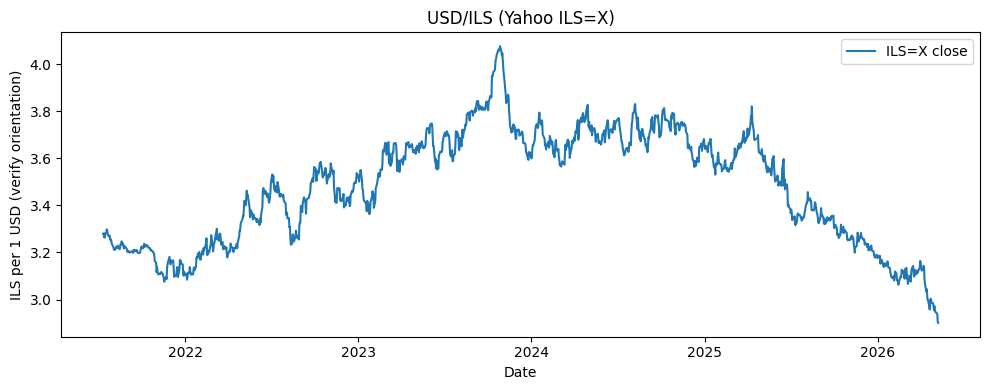

In [57]:
import matplotlib.pyplot as plt
import yfinance as yf

dmin = hist_df["pay_date_iso"].dropna().min()
dmax = hist_df["pay_date_iso"].dropna().max()
if pd.isna(dmin):
    dmin = hist_df["exec_date_iso"].dropna().min()
    dmax = hist_df["exec_date_iso"].dropna().max()

start = (pd.Timestamp(dmin) - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
end = (pd.Timestamp(dmax) + pd.Timedelta(days=5)).strftime("%Y-%m-%d")

fx = yf.download("ILS=X", start=start, end=end, progress=False, auto_adjust=False, threads=False)
if fx.empty:
    raise RuntimeError("No FX data from yfinance")

if isinstance(fx.columns, pd.MultiIndex):
    fx = fx.droplevel(1, axis=1)

fx = fx.reset_index()
fx["date_iso"] = pd.to_datetime(fx["Date"]).dt.strftime("%Y-%m-%d")
fx = fx.rename(columns={"Close": "ils_per_usd_close"})

join_col = JOIN_DATE_COL
hist_fx = hist_df.merge(
    fx[["date_iso", "ils_per_usd_close"]],
    left_on=join_col,
    right_on="date_iso",
    how="left",
)

missing_fx = hist_fx[join_col].notna() & hist_fx["ils_per_usd_close"].isna()
print("rows with date but no FX match", int(missing_fx.sum()))
display(hist_fx.loc[missing_fx, [join_col, "security_number", "name", "action"]].head(10))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pd.to_datetime(fx["date_iso"]), fx["ils_per_usd_close"], label="ILS=X close")
ax.set_title("USD/ILS (Yahoo ILS=X)")
ax.set_xlabel("Date")
ax.set_ylabel("ILS per 1 USD (verify orientation)")
ax.legend()
plt.tight_layout()
plt.show()

## Ticker resolution + prices (yfinance + optional OpenFIGI + manual CSV)

- **OpenFIGI** now receives **true ISINs** from the bank id (`is_isin`) **and** from **`maya_isin`** when Maya matched the security — so Israeli-listed funds like `IL0011481624` can map to a Bloomberg-style ticker even when the bank line is not an ISIN.
- **Name suffix heuristic**: many Leumi-style lines end with `) SPY`, `) UPRO`, `) VIG` — we parse Latin tickers after the closing `)` and use them for Yahoo.
- **`maya_symbol`**: when Maya lists `Smb` (e.g. `IBI.F65`), we try it as the **Yahoo ticker** before OpenFIGI (often best for Israeli listings).
- **Yahoo history**: daily `Close` merged on `JOIN_DATE_COL`.

In [58]:
OPENFIGI_URL = "https://api.openfigi.com/v3/mapping"
# OpenFIGI often returns 413 for “too large” bodies; limits vary. We use small chunks + split on 413.
OPENFIGI_ISIN_CHUNK = 8


def _openfigi_post_isin_chunk(chunk: list[str]) -> dict[str, str]:
    """POST one batch; on 413 recursively split the batch."""
    chunk = [c.upper().strip() for c in chunk if looks_like_isin(str(c))]
    if not chunk:
        return {}
    payload = [{"idType": "ID_ISIN", "idValue": i} for i in chunk]
    r = requests.post(
        OPENFIGI_URL,
        data=json.dumps(payload),
        headers={"Content-Type": "application/json"},
        timeout=120,
    )
    if r.status_code == 413:
        if len(chunk) <= 1:
            print("OpenFIGI 413: skipping single ISIN (too large or blocked):", chunk[0] if chunk else "")
            return {}
        mid = (len(chunk) + 1) // 2
        left = _openfigi_post_isin_chunk(chunk[:mid])
        right = _openfigi_post_isin_chunk(chunk[mid:])
        return {**left, **right}
    r.raise_for_status()
    body = r.json()
    if not isinstance(body, list) or len(body) != len(chunk):
        print("OpenFIGI warning: bad response", getattr(r, "status_code", None), "len", len(body) if isinstance(body, list) else body)
        return {}
    out: dict[str, str] = {}
    for isin, item in zip(chunk, body):
        res = item.get("data") or []
        if not res:
            continue
        first = res[0]
        t = first.get("ticker")
        ex = first.get("exchCode")
        if t and ex:
            out[isin] = f"{t}.{ex}"
        elif t:
            out[isin] = str(t)
    return out


def openfigi_isin_to_tickers(isins: list[str]) -> dict[str, str]:
    """Returns ISIN -> yahoo-like symbol (TICKER.EXCH) best-effort (batched POSTs)."""
    isins = sorted({i.upper().strip() for i in isins if looks_like_isin(str(i))})
    if not isins:
        return {}
    merged: dict[str, str] = {}
    for off in range(0, len(isins), OPENFIGI_ISIN_CHUNK):
        sub = isins[off : off + OPENFIGI_ISIN_CHUNK]
        merged.update(_openfigi_post_isin_chunk(sub))
    return merged


def load_manual_ticker_map(path: Path) -> dict[str, str]:
    if not path.is_file():
        return {}
    m = pd.read_csv(path, dtype=str)
    if "security_number" not in m.columns or "yahoo_ticker" not in m.columns:
        raise ValueError(f"{path} needs columns security_number,yahoo_ticker")
    return dict(zip(m["security_number"].str.strip(), m["yahoo_ticker"].str.strip()))


manual_map = load_manual_ticker_map(MANUAL_TICKER_CSV)
print("manual ticker rows", len(manual_map))

isin_candidates: list[str] = []
for _, r in hist_df.iterrows():
    sn = str(r.get("security_number", "")).strip()
    if looks_like_isin(sn):
        isin_candidates.append(sn.upper())
    mi = r.get("maya_isin")
    if mi is not None and not (isinstance(mi, float) and pd.isna(mi)):
        ms = str(mi).strip().upper()
        if looks_like_isin(ms):
            isin_candidates.append(ms)
isin_list = sorted(set(isin_candidates))
print("OpenFIGI ISIN candidates (bank id + Maya ISIN)", len(isin_list))
figi_map = openfigi_isin_to_tickers(isin_list)
print("OpenFIGI resolved", len(figi_map), "ISINs")


# Leumi-style names often end with ") SPY" / ") UPRO" — Latin ticker, not ISIN.
_NAME_TICKER_SUFFIX = re.compile(r"\)\s*([A-Z]{2,5})\s*$")


def guess_yahoo_from_bank_name(name: object) -> str | None:
    if name is None or (isinstance(name, float) and pd.isna(name)):
        return None
    s = str(name).strip()
    if not s:
        return None
    m = _NAME_TICKER_SUFFIX.search(s)
    return m.group(1) if m else None


def resolve_yahoo_ticker_row(row) -> tuple:
    """Returns (yahoo_symbol_or_None, source_or_None)."""
    sn = str(row["security_number"]).strip()
    if sn in manual_map:
        return manual_map[sn], "manual_csv"
    ms = row.get("maya_symbol")
    if ms is not None and not (isinstance(ms, float) and pd.isna(ms)):
        smb = str(ms).strip()
        if smb and smb.lower() != "nan":
            return smb, "maya_smb"
    if row.get("is_isin"):
        hit = figi_map.get(sn.upper())
        if hit:
            return hit, "openfigi_bank_id"
    mi = row.get("maya_isin")
    if mi is not None and not (isinstance(mi, float) and pd.isna(mi)):
        miu = str(mi).strip().upper()
        if looks_like_isin(miu):
            hit = figi_map.get(miu)
            if hit:
                return hit, "openfigi_maya_isin"
    g = guess_yahoo_from_bank_name(row.get("name"))
    if g:
        return g, "name_suffix"
    return None, None


_resolved = hist_fx.apply(resolve_yahoo_ticker_row, axis=1, result_type="expand")
hist_fx["yahoo_ticker"] = _resolved[0]
hist_fx["ticker_source"] = _resolved[1]
resolved = hist_fx["yahoo_ticker"].notna()
print("rows with yahoo_ticker", int(resolved.sum()), "/", len(hist_fx))
print("ticker_source counts:")
print(hist_fx["ticker_source"].value_counts(dropna=False).to_string())
display(hist_fx.loc[~resolved & hist_fx["security_number"].notna(), ["security_number", "name", "is_isin"]].drop_duplicates().head(20))

still_unresolved = (
    hist_fx.loc[hist_fx["yahoo_ticker"].isna(), ["security_number", "name"]]
    .drop_duplicates()
    .sort_values("security_number")
)
print("distinct securities still without Yahoo symbol", len(still_unresolved), "— add rows to", MANUAL_TICKER_CSV)
display(still_unresolved)

tickers = sorted(hist_fx.loc[resolved, "yahoo_ticker"].unique())
close_by_ticker: dict[str, pd.Series] = {}
for t in tickers:
    sub = yf.download(t, start=start, end=end, progress=False, auto_adjust=False, threads=False)
    if sub is None or sub.empty:
        continue
    if isinstance(sub.columns, pd.MultiIndex):
        sub = sub.droplevel(1, axis=1)
    s = sub["Close"].dropna()
    s.index = pd.to_datetime(s.index).strftime("%Y-%m-%d")
    close_by_ticker[t] = s


def lookup_close(row):
    sym = row.get("yahoo_ticker")
    d = row.get(join_col) or row.get("exec_date_iso")
    if not sym or not d:
        return None
    s = close_by_ticker.get(sym)
    if s is None:
        return None
    return s.get(d)


hist_fx["yahoo_close"] = hist_fx.apply(lookup_close, axis=1)
display(hist_fx[["security_number", "name", join_col, "yahoo_ticker", "yahoo_close", "ils_per_usd_close", "consideration", "currency"]].head(20))

manual ticker rows 5
OpenFIGI ISIN candidates (bank id + Maya ISIN) 13
OpenFIGI resolved 10 ISINs
rows with yahoo_ticker 99 / 115
ticker_source counts:
ticker_source
name_suffix           58
openfigi_maya_isin    23
None                  16
manual_csv            15
maya_smb               3


,security_number,name,is_isin
24,1201508,הראל אלפי בנדק US Equity AI QUANT Strategy - ק...,False
25,1194182,"הראל אסטרטגיות מניות חו""ל - קרן גידור בנאמנות",False
26,1210764,הרל.seqai 08/24,False
27,1210756,הרל.אסמנח 08/24,False
30,5135280,"אי בי אי מחקה EURO STOXX Dividend 30 מנוטרלת מט""ח",False
40,5129259,אי בי אי מחקה S&P Health Care,False
54,1194976,הראל אסטרטגיות מניות חול גידור 03/23,False


distinct securities still without Yahoo symbol 7 — add rows to c:\DEV\FinCompiler\notebooks\security_yahoo_map.csv


,security_number,name
25,1194182,"הראל אסטרטגיות מניות חו""ל - קרן גידור בנאמנות"
54,1194976,הראל אסטרטגיות מניות חול גידור 03/23
24,1201508,הראל אלפי בנדק US Equity AI QUANT Strategy - ק...
27,1210756,הרל.אסמנח 08/24
26,1210764,הרל.seqai 08/24
40,5129259,אי בי אי מחקה S&P Health Care
30,5135280,"אי בי אי מחקה EURO STOXX Dividend 30 מנוטרלת מט""ח"


$ALOPTIO.IT: possibly delisted; no timezone found

1 Failed download:
['ALOPTIO.IT']: possibly delisted; no timezone found
$ASP5FCI.IT: possibly delisted; no timezone found

1 Failed download:
['ASP5FCI.IT']: possibly delisted; no timezone found
$DOL00MI.IT: possibly delisted; no timezone found

1 Failed download:
['DOL00MI.IT']: possibly delisted; no timezone found
$IBI.F65: possibly delisted; no timezone found

1 Failed download:
['IBI.F65']: possibly delisted; no timezone found
$MSHKDBI.IT: possibly delisted; no timezone found

1 Failed download:
['MSHKDBI.IT']: possibly delisted; no timezone found
$PIAYAHA.IT: possibly delisted; no timezone found

1 Failed download:
['PIAYAHA.IT']: possibly delisted; no timezone found


,security_number,name,pay_date_iso,yahoo_ticker,yahoo_close,ils_per_usd_close,consideration,currency
0,60013157,(ספיידר S&P 500) SPY,2023-10-31,SPY,418.200012,4.03678,20.58,"דולר ארה""ב"
1,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,2023-09-27,UPRO,40.840000,3.82483,0.34,"דולר ארה""ב"
2,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,2023-09-27,UPRO,40.840000,3.82483,-0.34,"דולר ארה""ב"
3,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,2023-09-07,UPRO,46.480000,3.82480,-290.64,"דולר ארה""ב"
4,60013157,(ספיידר S&P 500) SPY,2023-08-24,SPY,436.890015,3.76037,-5702.45,"דולר ארה""ב"
5,720011,אנלייט אנרגיה,2023-08-21,ENLT,16.700001,3.79370,0.00,"ש""ח"
6,1148162,אי בי אי סל S&P 500,2023-08-17,IBI.F65,NaN,3.74967,-4887.00,"ש""ח"
7,1148162,אי בי אי סל S&P 500,2023-08-15,IBI.F65,NaN,3.74315,-11920.90,"ש""ח"
8,60013157,(ספיידר S&P 500) SPY,2024-04-30,SPY,501.980011,3.76072,20.73,"דולר ארה""ב"
9,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,2024-03-27,UPRO,70.589996,3.66640,0.74,"דולר ארה""ב"


In [59]:
# --- Export enriched CSV for a future ledger injector (read-only on SQLite) ---

ENRICHED_DIR.mkdir(parents=True, exist_ok=True)
out_csv = ENRICHED_DIR / "hist_movements_enriched.csv"
hist_fx.to_csv(out_csv, index=False)
print("Wrote", out_csv, "rows", len(hist_fx))

Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_movements_enriched.csv rows 115


## Summary: what past market data can we attach?

Per **`security_number`** (aggregated over all historical movement rows below): whether **TASE/Maya** returned a **native** price on at least one row date, whether **Yahoo** returned a **close**, and a **coverage lane**. Rows with **Maya metadata** but zero `maya_native_close` usually mean the instrument is on Maya but that calendar day had no match (weekend/holiday), the id did not match, or price fetch was skipped.

In [60]:
# --- Coverage summary per security (requires hist_fx from prior cells) ---

_maya_cols = [c for c in ("maya_name_en", "maya_isin", "maya_symbol") if c in hist_fx.columns]


def _first_nonempty(series) -> str:
    s = series.dropna().astype(str).str.strip()
    s = s[s.str.len() > 0]
    return s.iloc[0] if len(s) else ""


summary_rows: list[dict] = []
for sn, sub in hist_fx.groupby("security_number", dropna=False):
    name = _first_nonempty(sub["name"]) if "name" in sub.columns else ""
    maya_meta = bool(_maya_cols) and any(sub[c].notna().any() for c in _maya_cols)
    maya_px = (
        int(sub["maya_native_close"].notna().sum())
        if "maya_native_close" in sub.columns
        else 0
    )
    y_sym = sub["yahoo_ticker"].notna().any() if "yahoo_ticker" in sub.columns else False
    y_tick = _first_nonempty(sub["yahoo_ticker"]) if "yahoo_ticker" in sub.columns else ""
    y_px = int(sub["yahoo_close"].notna().sum()) if "yahoo_close" in sub.columns else 0
    fx_px = (
        int(sub["ils_per_usd_close"].notna().sum())
        if "ils_per_usd_close" in sub.columns
        else 0
    )
    ts = ""
    if "ticker_source" in sub.columns:
        ts = ";".join(sorted({str(x) for x in sub["ticker_source"].dropna().unique()}))

    if maya_px > 0 and y_px > 0:
        lane = "Maya_price + Yahoo_close"
    elif maya_px > 0:
        lane = "Maya_price only (TASE line on some hist dates)"
    elif y_px > 0:
        lane = "Yahoo_close only"
    elif maya_meta:
        lane = "Maya metadata only (no native price on hist row dates)"
    elif y_sym:
        lane = "Yahoo ticker but no close (404/delisted/bad symbol/date gap)"
    else:
        lane = "No Maya match and no Yahoo symbol (manual CSV or unsupported id)"

    summary_rows.append(
        {
            "security_number": sn,
            "name_sample": (name[:70] + "…") if len(name) > 70 else name,
            "hist_movement_rows": len(sub),
            "maya_universe_match": maya_meta,
            "rows_with_maya_native_close": maya_px,
            "rows_with_yahoo_close": y_px,
            "rows_with_fx": fx_px,
            "yahoo_ticker_sample": y_tick,
            "ticker_sources": ts,
            "coverage_lane": lane,
        }
    )

coverage_summary = pd.DataFrame(summary_rows).sort_values(
    ["coverage_lane", "security_number"]
)
print("Securities count by coverage lane:")
print(coverage_summary["coverage_lane"].value_counts().to_string())
print()
display(coverage_summary)

weak = coverage_summary[
    coverage_summary["coverage_lane"].eq(
        "No Maya match and no Yahoo symbol (manual CSV or unsupported id)"
    )
    | coverage_summary["coverage_lane"].str.contains("Yahoo ticker but no close", regex=False)
    | coverage_summary["coverage_lane"].str.contains("Maya metadata only", regex=False)
].copy()
print(
    "\nSecurities with limited or no vendor security-level history:",
    len(weak),
    "— extend security_yahoo_map.csv, fix Yahoo symbols, or rely on Maya-only dates."
)
display(
    weak[
        [
            "security_number",
            "name_sample",
            "coverage_lane",
            "yahoo_ticker_sample",
            "ticker_sources",
            "rows_with_maya_native_close",
            "rows_with_yahoo_close",
        ]
    ]
)

Securities count by coverage lane:
coverage_lane
Maya metadata only (no native price on hist row dates)              9
Yahoo_close only                                                    8
Maya_price + Yahoo_close                                            3
No Maya match and no Yahoo symbol (manual CSV or unsupported id)    3
Maya_price only (TASE line on some hist dates)                      1



,security_number,name_sample,hist_movement_rows,maya_universe_match,rows_with_maya_native_close,rows_with_yahoo_close,rows_with_fx,yahoo_ticker_sample,ticker_sources,coverage_lane
3,1194182,"הראל אסטרטגיות מניות חו""ל - קרן גידור בנאמנות",2,True,0,0,2,,,Maya metadata only (no native price on hist ro...
4,1194976,הראל אסטרטגיות מניות חול גידור 03/23,2,True,0,0,1,,,Maya metadata only (no native price on hist ro...
8,5105531,אלטשולר שחם S&P 500,3,True,0,0,2,MSHKDBI.IT,openfigi_maya_isin,Maya metadata only (no native price on hist ro...
9,5105895,אלטשולר שחם - קרן ממונפת,3,True,0,0,2,ALOPTIO.IT,openfigi_maya_isin,Maya metadata only (no native price on hist ro...
10,5110374,הראל מניות דיבידנד,2,True,0,0,2,PIAYAHA.IT,openfigi_maya_isin,Maya metadata only (no native price on hist ro...
12,5129259,אי בי אי מחקה S&P Health Care,2,True,0,0,2,,,Maya metadata only (no native price on hist ro...
14,5135280,"אי בי אי מחקה EURO STOXX Dividend 30 מנוטרלת מט""ח",2,True,0,0,2,,,Maya metadata only (no native price on hist ro...
15,5138037,"אלטשולר שחם S&P 500 - מנוטרלת מט""ח",3,True,0,0,2,ASP5FCI.IT,openfigi_maya_isin,Maya metadata only (no native price on hist ro...
16,5138698,דולפין כספית,12,True,0,0,12,DOL00MI.IT,openfigi_maya_isin,Maya metadata only (no native price on hist ro...
0,1146067,קסם DJ US Dividend ETF,1,True,1,1,1,DVY,manual_csv,Maya_price + Yahoo_close



Securities with limited or no vendor security-level history: 12 — extend security_yahoo_map.csv, fix Yahoo symbols, or rely on Maya-only dates.


,security_number,name_sample,coverage_lane,yahoo_ticker_sample,ticker_sources,rows_with_maya_native_close,rows_with_yahoo_close
3,1194182,"הראל אסטרטגיות מניות חו""ל - קרן גידור בנאמנות",Maya metadata only (no native price on hist ro...,,,0,0
4,1194976,הראל אסטרטגיות מניות חול גידור 03/23,Maya metadata only (no native price on hist ro...,,,0,0
8,5105531,אלטשולר שחם S&P 500,Maya metadata only (no native price on hist ro...,MSHKDBI.IT,openfigi_maya_isin,0,0
9,5105895,אלטשולר שחם - קרן ממונפת,Maya metadata only (no native price on hist ro...,ALOPTIO.IT,openfigi_maya_isin,0,0
10,5110374,הראל מניות דיבידנד,Maya metadata only (no native price on hist ro...,PIAYAHA.IT,openfigi_maya_isin,0,0
12,5129259,אי בי אי מחקה S&P Health Care,Maya metadata only (no native price on hist ro...,,,0,0
14,5135280,"אי בי אי מחקה EURO STOXX Dividend 30 מנוטרלת מט""ח",Maya metadata only (no native price on hist ro...,,,0,0
15,5138037,"אלטשולר שחם S&P 500 - מנוטרלת מט""ח",Maya metadata only (no native price on hist ro...,ASP5FCI.IT,openfigi_maya_isin,0,0
16,5138698,דולפין כספית,Maya metadata only (no native price on hist ro...,DOL00MI.IT,openfigi_maya_isin,0,0
5,1201508,הראל אלפי בנדק US Equity AI QUANT Strategy - ק...,No Maya match and no Yahoo symbol (manual CSV ...,,,0,0


## Portfolio valuation CSV (ledger-oriented)

One row per **valuation date** per **holding segment**: segment open, each **1st and 15th** of the month while held, and segment close (if closed). Uses the same **`event_date`** convention as holding windows (`JOIN_DATE_COL` then `exec_date_iso`).

**Prices**: Maya native closes from `hist_fx` when available for that security (last on or before the date); otherwise Yahoo `close_by_ticker`. **FX**: `ILS=X` close as **`ils_per_usd_close`** (ILS per 1 USD). **`value_ils`**: for USD-denominated lines (bank `currency` contains `דולר` or `USD`), `quantity * last_price * ils_per_usd_close`; for ILS lines, `quantity * last_price` (using **display** price before ledger scaling).

**`last_price` in the CSV** matches SQLite storage: **display quote ÷ `price_multiplier`** from `data/ledger.sqlite` when present (API shows `last_price * price_multiplier`). Optional CSV column **`price_multiplier`** is set when the multiplier is not 1 so [`tools/import_hist_portfolio_valuation.py`](tools/import_hist_portfolio_valuation.py) can persist it.

Extra columns vs SQLite `trade_portfolio_position`: `valuation_kind`, `yahoo_ticker`, `price_source`, `segment_index`, optional `price_multiplier`. Map `snapshot_date`, `security_number`, `portfolio_account`, `quantity`, `last_price`, `value_ils` for import tooling.


In [62]:
# --- Portfolio valuation time series (ledger import CSV) — run after hist_fx + FX + Yahoo cells ---

if "close_by_ticker" not in dir():
    raise RuntimeError("Run the Yahoo / close_by_ticker cell first.")

if "fx" not in dir() or fx is None or fx.empty:
    raise RuntimeError("Run the ILS=X / fx cell first.")

join_col = JOIN_DATE_COL if "JOIN_DATE_COL" in dir() else "pay_date_iso"

_hw = hist_fx.copy()
_hw["event_date"] = pd.to_datetime(
    _hw[join_col].fillna(_hw["exec_date_iso"]),
    errors="coerce",
)
_hw["quantity"] = pd.to_numeric(_hw["quantity"], errors="coerce")
pos = _hw[
    _hw["event_date"].notna()
    & _hw["quantity"].notna()
    & (_hw["quantity"] != 0)
].copy()
pos = pos.sort_values(
    ["security_number", "event_date", "source_file"],
    kind="mergesort",
).reset_index(drop=True)


def _holding_segments_one_security(sub: pd.DataFrame) -> tuple[list[dict], float]:
    sub = sub.sort_values(["event_date", "source_file"], kind="mergesort")
    cum = 0.0
    open_date = None
    run_max = 0.0
    segs: list[dict] = []
    seg_ix = 0
    for _, r in sub.iterrows():
        prev = cum
        q = float(r["quantity"])
        d = r["event_date"]
        cum += q
        if open_date is None and prev <= 0 and cum > 0:
            open_date = d
            run_max = cum
        elif open_date is not None:
            run_max = max(run_max, cum)
        if open_date is not None and prev > 0 and cum <= 0:
            segs.append(
                {
                    "segment_index": seg_ix,
                    "open_date": open_date,
                    "close_date": d,
                    "peak_qty": run_max,
                    "still_open": False,
                }
            )
            seg_ix += 1
            open_date = None
            run_max = 0.0
    if open_date is not None and cum > 0:
        segs.append(
            {
                "segment_index": seg_ix,
                "open_date": open_date,
                "close_date": None,
                "peak_qty": run_max,
                "still_open": True,
            }
        )
    return segs, cum


def _add_segment_index(pos_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    for sn, g in pos_df.groupby("security_number", sort=True):
        g = g.sort_values(["event_date", "source_file"], kind="mergesort")
        seg = -1
        cum = 0.0
        for _, r in g.iterrows():
            prev = cum
            q = float(r["quantity"])
            cum += q
            if prev <= 0 and cum > 0:
                seg += 1
            rr = r.to_dict()
            rr["segment_index"] = seg
            rows.append(rr)
    return pd.DataFrame(rows)


pos_tag = _add_segment_index(pos)

seg_rows: list[dict] = []
for sn, g in pos.groupby("security_number", sort=True):
    g_ord = g.sort_values(["event_date", "source_file"], kind="mergesort")
    segs, _fq = _holding_segments_one_security(g_ord)
    for s in segs:
        seg_rows.append({"security_number": sn, **s})
hist_holding_segments_run = pd.DataFrame(seg_rows)

fx_idx = pd.Series(
    fx["ils_per_usd_close"].astype(float).values,
    index=pd.to_datetime(fx["date_iso"]).dt.normalize(),
).sort_index()


def _fx_on_or_before(d: pd.Timestamp) -> float | None:
    d0 = pd.Timestamp(d).normalize()
    sub = fx_idx[fx_idx.index <= d0]
    if sub.empty:
        return None
    return float(sub.iloc[-1])


def _close_on_or_before(s: pd.Series | None, d: pd.Timestamp) -> float | None:
    if s is None or s.empty:
        return None
    ds = pd.Timestamp(d).strftime("%Y-%m-%d")
    idx = pd.Index(s.index.astype(str))
    if ds in idx:
        return float(s.loc[ds])
    sub = s[idx <= ds]
    if sub.empty:
        return None
    return float(sub.iloc[-1])


_yahoo_by_sec: dict[str, str] = {}
for sn, g in hist_fx.groupby("security_number", sort=True):
    sn_s = str(sn).strip()
    for _, r in g.iterrows():
        sym, _src = resolve_yahoo_ticker_row(r)
        if sym:
            _yahoo_by_sec[sn_s] = sym
            break

_maya_series: dict[str, pd.Series] = {}
_dense_maya = globals().get("maya_close_series_by_security") or {}
if isinstance(_dense_maya, dict) and _dense_maya:
    for _sn, _ser in _dense_maya.items():
        _sn_k = str(_sn).strip()
        if _ser is not None and len(_ser) > 0:
            _maya_series[_sn_k] = _ser.astype(float).sort_index()
for sn, g in hist_fx.groupby("security_number", sort=True):
    sn_s = str(sn).strip()
    if sn_s in _maya_series:
        continue
    if "maya_native_close" not in g.columns:
        continue
    g2 = g[pd.notna(g["maya_native_close"])]
    if g2.empty:
        continue
    dcol = pd.to_datetime(g2[join_col].fillna(g2["exec_date_iso"]), errors="coerce")
    s = pd.Series(g2["maya_native_close"].astype(float).values, index=dcol.dt.strftime("%Y-%m-%d"))
    s = s.groupby(level=0).last().sort_index()
    _maya_series[sn_s] = s


def _is_usd_security(sn: str) -> bool:
    sub = hist_fx[hist_fx["security_number"].astype(str).str.strip() == sn]
    if "currency" not in sub.columns or sub["currency"].isna().all():
        return False
    cur = sub["currency"].dropna().astype(str)
    return bool(cur.str.contains("דולר", regex=False).any() | cur.str.upper().str.contains("USD").any())


def _first_name(sn: str) -> str:
    sub = hist_fx[hist_fx["security_number"].astype(str).str.strip() == sn]["name"]
    sub = sub.dropna().astype(str).str.strip()
    return sub.iloc[0] if len(sub) else ""


_portfolio_acct = None
if "portfolio_account" in hist_fx.columns:
    p = hist_fx["portfolio_account"].dropna()
    if len(p):
        _portfolio_acct = str(p.iloc[0])

# Ledger quote scaling: API uses last_price * price_multiplier as display quote.
_ledger_db_path = REPO_ROOT / "data" / "ledger.sqlite"
_price_mult_by_sec: dict[str, float] = {}
_pa = _portfolio_acct or ""
if _ledger_db_path.is_file() and _pa:
    _conn = sqlite3.connect(str(_ledger_db_path))
    try:
        for _sec, _pm in _conn.execute(
            "SELECT security_number, price_multiplier FROM trade_portfolio_position_multiplier "
            "WHERE portfolio_account = ?",
            (_pa,),
        ):
            _price_mult_by_sec[str(_sec).strip()] = float(_pm)
    finally:
        _conn.close()

hist_holding_segments.to_csv(_hist_seg_csv, index=False)
hist_holding_security_rollup.to_csv(_hist_roll_csv, index=False)
hist_security_name_timeline.to_csv(_hist_names_csv, index=False)
print("Wrote", _hist_seg_csv)
print("Wrote", _hist_roll_csv)
print("Wrote", _hist_names_csv)



def _monthly_checkpoints(a: pd.Timestamp, b: pd.Timestamp) -> list[pd.Timestamp]:
    a0 = pd.Timestamp(a).normalize()
    b0 = pd.Timestamp(b).normalize()
    out: list[pd.Timestamp] = []
    cur = pd.Timestamp(a0.year, a0.month, 1)
    while cur <= b0:
        for dom in (1, 15):
            d = pd.Timestamp(cur.year, cur.month, dom)
            if a0 <= d <= b0:
                out.append(d)
        cur = cur + pd.offsets.MonthBegin(1)
    return out


def _valuation_kind(d: pd.Timestamp, open_d, close_d) -> str:
    d0 = pd.Timestamp(d).normalize()
    o0 = pd.Timestamp(open_d).normalize()
    kinds: list[str] = []
    if d0 == o0:
        kinds.append("segment_open")
    if close_d is not None and not pd.isna(close_d) and d0 == pd.Timestamp(close_d).normalize():
        kinds.append("segment_close")
    if d0.day == 1:
        kinds.append("month_01")
    if d0.day == 15:
        kinds.append("month_15")
    if not kinds:
        kinds.append("checkpoint")
    return "+".join(kinds)


horizon = pos["event_date"].max()
out_rows: list[dict] = []

for _, seg in hist_holding_segments_run.iterrows():
    sn = str(seg["security_number"]).strip()
    seg_ix = int(seg["segment_index"])
    open_d = seg["open_date"]
    close_d = seg["close_date"]
    still_open = bool(seg.get("still_open", pd.isna(close_d)))

    if open_d is None or (isinstance(open_d, float) and pd.isna(open_d)):
        continue
    open_d = pd.Timestamp(open_d).normalize()
    end_d = (
        pd.Timestamp(close_d).normalize()
        if close_d is not None and not pd.isna(close_d)
        else pd.Timestamp(horizon).normalize()
    )

    val_dates = {open_d}
    if close_d is not None and not pd.isna(close_d):
        val_dates.add(pd.Timestamp(close_d).normalize())
    for md in _monthly_checkpoints(open_d, end_d):
        val_dates.add(pd.Timestamp(md).normalize())
    val_dates = sorted(val_dates)

    ysym = _yahoo_by_sec.get(sn)
    maya_s = _maya_series.get(sn)
    usd_line = _is_usd_security(sn)
    name0 = _first_name(sn)

    for vd in val_dates:
        vd = pd.Timestamp(vd).normalize()
        mask = (
            (pos_tag["security_number"].astype(str).str.strip() == sn)
            & (pos_tag["segment_index"] == seg_ix)
            & (pos_tag["event_date"] <= vd)
        )
        qty = float(pos_tag.loc[mask, "quantity"].sum())

        last_px = None
        px_src = ""
        if maya_s is not None:
            last_px = _close_on_or_before(maya_s, vd)
            if last_px is not None:
                px_src = "maya_native"
        if last_px is None and ysym and ysym in close_by_ticker:
            last_px = _close_on_or_before(close_by_ticker[ysym], vd)
            if last_px is not None:
                px_src = "yahoo"

        mult = float(_price_mult_by_sec.get(sn, 1.0))
        if mult <= 0:
            mult = 1.0
        last_px_db = (last_px / mult) if last_px is not None else None

        ils_rate = _fx_on_or_before(vd)
        value_ils = None
        if last_px is not None and qty != 0:
            if usd_line and ils_rate is not None:
                value_ils = qty * last_px * ils_rate
            else:
                value_ils = qty * last_px

        _row = {
            "snapshot_date": vd.strftime("%Y-%m-%d"),
            "portfolio_account": _portfolio_acct or "",
            "security_number": sn,
            "security_name": name0,
            "segment_index": seg_ix,
            "valuation_kind": _valuation_kind(vd, open_d, close_d if not still_open else None),
            "quantity": qty,
            "last_price": (last_px_db * mult) if mult is not None and last_px_db is not None else last_px_db,
            "value_ils": value_ils,
            "real_value": (value_ils * mult) if value_ils is not None else None,
            "ils_per_usd_close": ils_rate,
            "yahoo_ticker": ysym or "",
            "price_source": px_src,
            "is_usd_denominated": usd_line,
        }
        if mult != 1.0:
            _row["price_multiplier"] = mult
        out_rows.append(_row)

hist_portfolio_valuation_series = pd.DataFrame(out_rows)
hist_portfolio_valuation_series = hist_portfolio_valuation_series.sort_values(
    ["snapshot_date", "security_number", "segment_index"]
).reset_index(drop=True)

out_portfolio_csv = ENRICHED_DIR / "hist_portfolio_valuation_series.csv"
ENRICHED_DIR.mkdir(parents=True, exist_ok=True)
hist_portfolio_valuation_series.to_csv(out_portfolio_csv, index=False)
print("Wrote", out_portfolio_csv, "rows", len(hist_portfolio_valuation_series))
display(hist_portfolio_valuation_series.tail(25))


Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_holding_segments.csv
Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_holding_security_rollup.csv
Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_security_name_timeline.csv
Wrote c:\DEV\FinCompiler\hist-data\enriched\hist_portfolio_valuation_series.csv rows 436


,snapshot_date,portfolio_account,security_number,security_name,segment_index,valuation_kind,quantity,last_price,value_ils,real_value,ils_per_usd_close,yahoo_ticker,price_source,is_usd_denominated,price_multiplier
411,2026-03-15,954-037317/51,1148162,אי בי אי סל S&P 500,0,month_15,103.00,20740.000000,2.136220e+06,21362.200000,3.13042,IBI.F65,maya_native,False,0.01
412,2026-03-15,954-037317/51,1194976,הראל אסטרטגיות מניות חול גידור 03/23,0,month_15,229.67,NaN,NaN,NaN,3.13042,,,False,NaN
413,2026-03-15,954-037317/51,60007953,(אינטל) INTC,0,month_15,16.00,45.770000,2.292469e+03,2292.469175,3.13042,INTC,yahoo,True,NaN
414,2026-03-15,954-037317/51,60013157,(ספיידר S&P 500) SPY,0,month_15,13.00,662.289978,2.695220e+04,26952.195047,3.13042,SPY,yahoo,True,NaN
415,2026-03-15,954-037317/51,60126357,(פרו-שיירס אולטרה-פרו S&P 500) UPRO,0,month_15,6.00,103.010002,1.934787e+03,1934.787407,3.13042,UPRO,yahoo,True,NaN
416,2026-04-01,954-037317/51,1146067,קסם DJ US Dividend ETF,0,month_01,14.00,3568.000000,4.995200e+04,499.520000,3.15470,DVY,maya_native,False,0.01
417,2026-04-01,954-037317/51,1148162,אי בי אי סל S&P 500,0,month_01,103.00,20110.000000,2.071330e+06,20713.300000,3.15470,IBI.F65,maya_native,False,0.01
418,2026-04-01,954-037317/51,1194976,הראל אסטרטגיות מניות חול גידור 03/23,0,month_01,229.67,NaN,NaN,NaN,3.15470,,,False,NaN
419,2026-04-01,954-037317/51,60007953,(אינטל) INTC,0,month_01,16.00,48.029999,2.424324e+03,2424.323826,3.15470,INTC,yahoo,True,NaN
420,2026-04-01,954-037317/51,60013157,(ספיידר S&P 500) SPY,0,month_01,13.00,655.239990,2.687211e+04,26872.113111,3.15470,SPY,yahoo,True,NaN
